#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Load the complete Titanic dataset from seaborn
df = sns.load_dataset('titanic')

# Display the first few rows and column information to confirm the presence of necessary columns
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Handle missing values using fillna() or dropna() — justify your choice in a markdown note

In [6]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))

df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop(columns=['deck'], inplace=True, errors='ignore')

#Create at least 4 visualizations using matplotlib and seaborn: a histogram, a boxplot, a bar chart, and a correlation heatmap

/tmp/ipykernel_1575/1918684352.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='survived', y='age', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_1575/1918684352.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Died (0)', 'Survived (1)'])
/tmp/ipykernel_1575/1918684352.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', ax=axes[1, 0], errorbar=None, palette='muted')


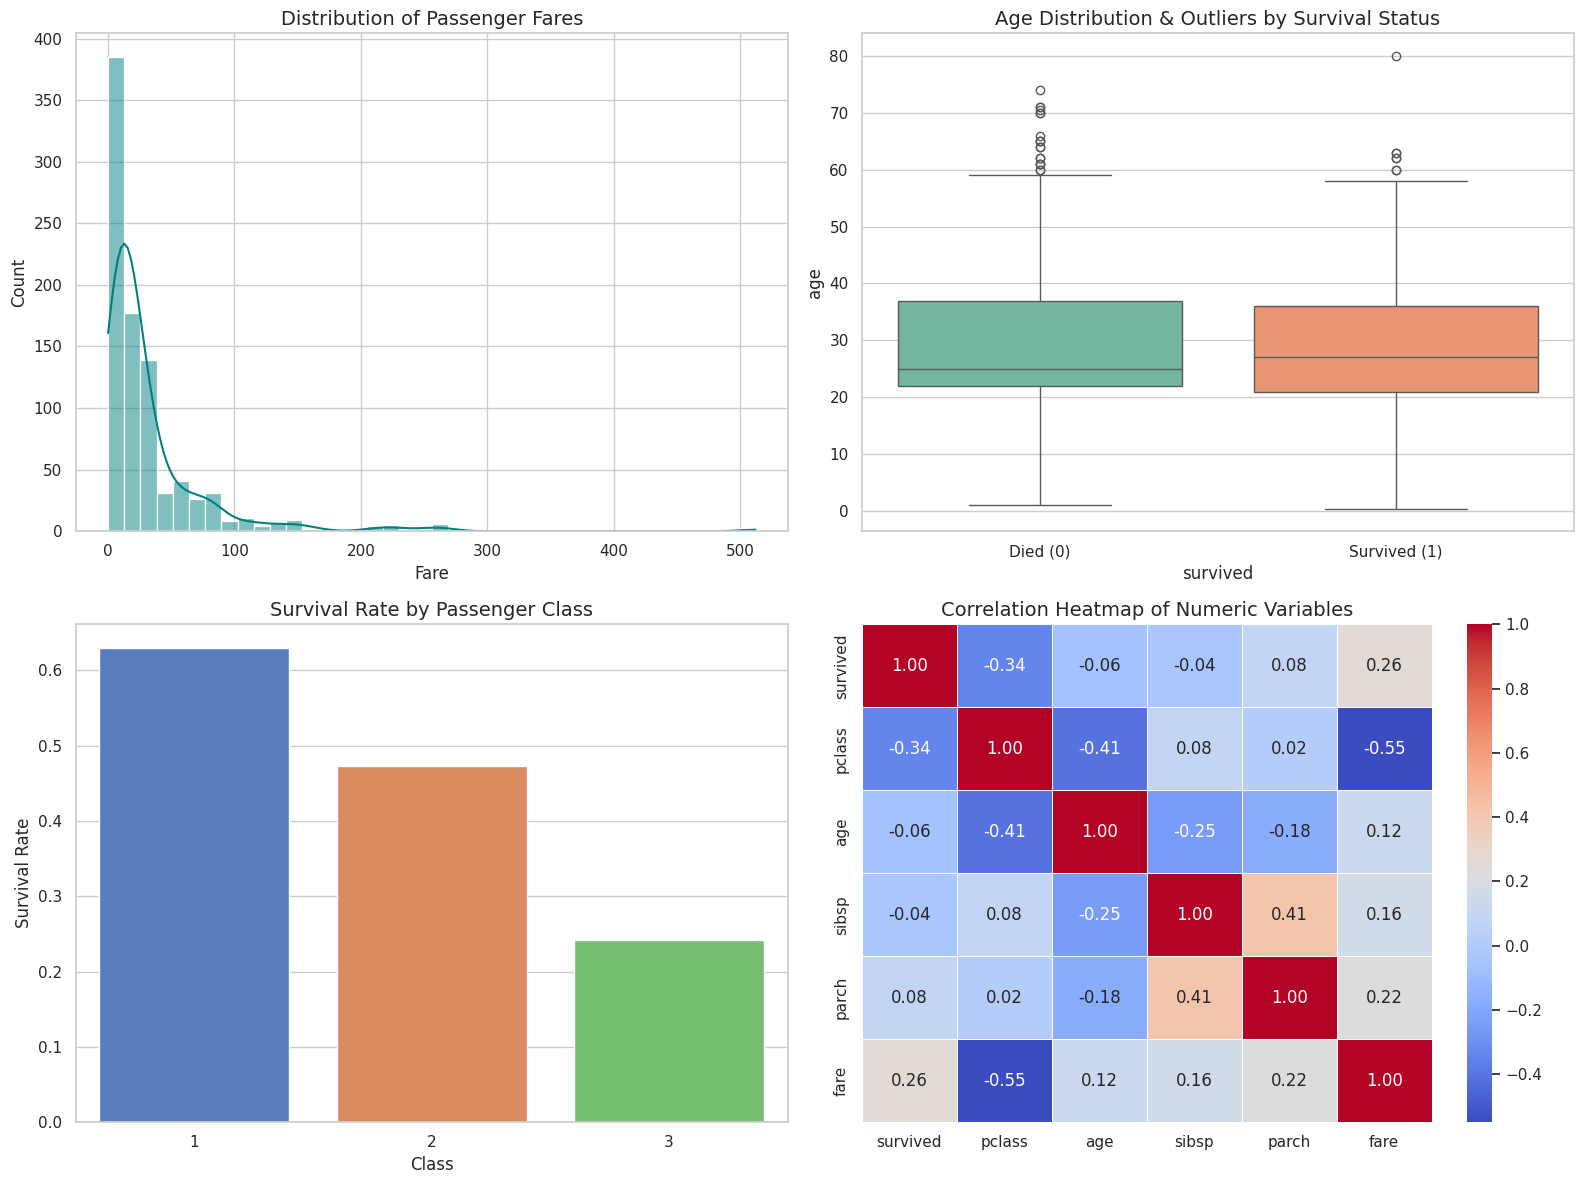

In [10]:
# Set the styling theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. HISTOGRAM: Distribution of Ticket Fares
sns.histplot(data=df, x='fare', kde=True, bins=40, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Passenger Fares', fontsize=14)
axes[0, 0].set_xlabel('Fare')

# 2. BOXPLOT: Detecting Outliers in Age by Survival
sns.boxplot(data=df, x='survived', y='age', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Age Distribution & Outliers by Survival Status', fontsize=14)
axes[0, 1].set_xticklabels(['Died (0)', 'Survived (1)'])

# 3. BAR CHART: Survival Rates Across Passenger Classes
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1, 0], errorbar=None, palette='muted')
axes[1, 0].set_title('Survival Rate by Passenger Class', fontsize=14)
axes[1, 0].set_ylabel('Survival Rate')
axes[1, 0].set_xlabel('Class')

# 4. CORRELATION HEATMAP: Numeric features
# Filter for only numeric columns to avoid string conversion errors
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap of Numeric Variables', fontsize=14)

plt.tight_layout()
plt.show()

**Which feature do you think most affects survival, and why?**

Based on the visualizations, the passenger class (pclass) appears to be the feature that most affects survival. Here's why:

**Bar Chart:** Survival Rate by Passenger Class: This chart directly shows a stark difference in survival rates across the passenger classes. Passengers in pclass=1 (first class) have a significantly higher survival rate compared to those in pclass=2 and especially pclass=3. This indicates a strong relationship between social-economic status (represented by class) and survival chances.
**Correlation Heatmap:** While not explicitly showing categorical variables like 'sex', the heatmap for numeric features likely reinforces this. pclass typically shows a strong negative correlation with survived (meaning lower class number, i.e., higher class, is associated with higher survival). fare also has a positive correlation, which is generally linked to higher classes.